In [1]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [3]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [4]:
df["survived"].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

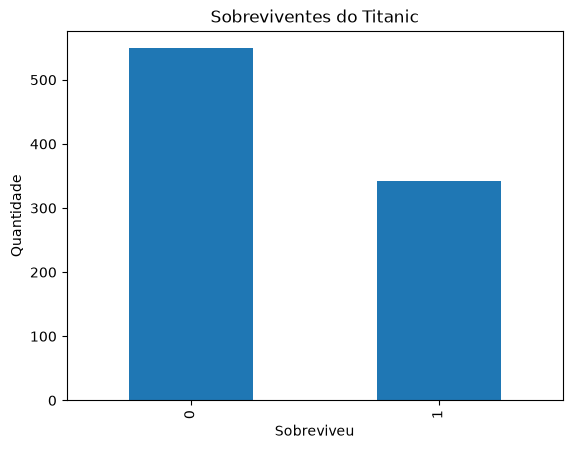

In [5]:
import matplotlib.pyplot as plt

df["survived"].value_counts().plot(kind="bar")

plt.title("Sobreviventes do Titanic")
plt.xlabel("Sobreviveu")
plt.ylabel("Quantidade")

plt.show()

In [6]:
df.groupby("sex")["survived"].mean()

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

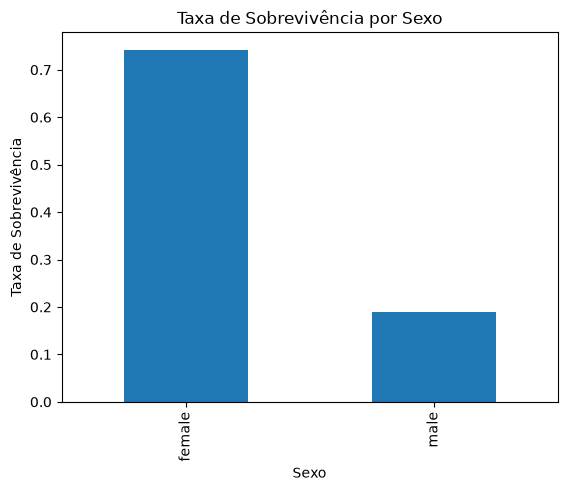

In [7]:
df.groupby("sex")["survived"].mean().plot(kind="bar")

plt.title("Taxa de Sobrevivência por Sexo")
plt.xlabel("Sexo")
plt.ylabel("Taxa de Sobrevivência")

plt.show()

In [8]:
df.groupby("class")["survived"].mean()

class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64

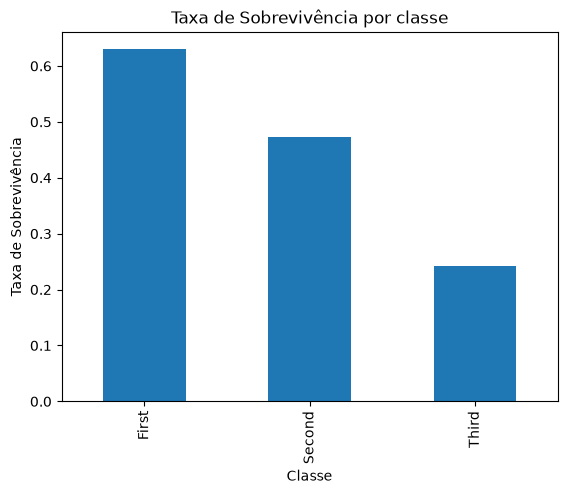

In [9]:
df.groupby("class")["survived"].mean().plot(kind="bar")

plt.title("Taxa de Sobrevivência por classe")
plt.xlabel("Classe")
plt.ylabel("Taxa de Sobrevivência")

plt.show()

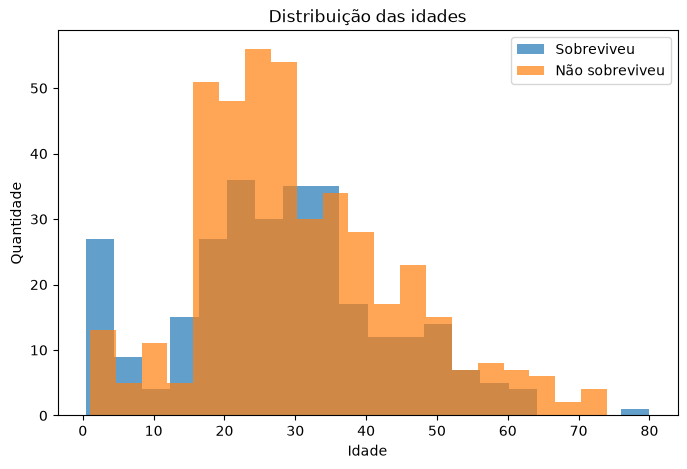

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df[df["survived"] == 1]["age"].dropna(),
         bins=20,
         alpha=0.7,
         label="Sobreviveu")

plt.hist(df[df["survived"] == 0]["age"].dropna(),
         bins=20,
         alpha=0.7,
         label="Não sobreviveu")

plt.title("Distribuição das idades")
plt.xlabel("Idade")
plt.ylabel("Quantidade")
plt.legend()

plt.show()

In [11]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [12]:
df = df.drop(columns=[
    "class",
    "who",
    "adult_male",
    "deck",
    "embark_town",
    "alive",
    "alone"
])

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [13]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked'],
      dtype='str')

In [14]:
df.isnull().sum()

survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64

In [15]:
df["age"].median()

np.float64(28.0)

In [16]:
df["age"] = df["age"].fillna(df["age"].median())

In [17]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

In [18]:
df.isnull().sum()


survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

In [19]:
df["sex"] = df["sex"].map({
    "male": 0,
    "female": 1
})

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,0,22.0,1,0,7.2500,S
1,1,1,1,38.0,1,0,71.2833,C
2,1,3,1,26.0,0,0,7.9250,S
3,1,1,1,35.0,1,0,53.1000,S
4,0,3,0,35.0,0,0,8.0500,S


In [20]:
df["embarked"] = df["embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    int64  
 3   age       891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB
